In [12]:
using LinearAlgebra
using Plots
using Statistics

# Questão 1. Cálculo dos refletores

$(a)$ Temos $Q_vx=||x||_2e_1$, então:
$$(I−\beta vv^*)x=||x||_2e_1$$

$$\beta(v^*x)v = x - ||x||_2e_1$$

como $\beta(v^*x)$ é um escalar, estamos interessados somente na direção do vetor. podemos escolher:
$$v = x - ||x||_2e_1$$

Para isso, queremos $\beta(v^*x) = 1$. substituindo:
$$v^*x = (x - ||x||_2 e_1)^* x = ||x||_2^2 - ||x||_2x_1$$
$$= ||x||_2(||x||_2 - x_1)$$

Portanto:
$$\beta = \frac{1}{||x||_2(||x||_2 - x_1)}$$

Queremos obter as outras formas de calcular $\beta$:
$$\beta = \frac{1}{||x||_2(||x||_2 - x_1)} \cdot \frac{||x||_2 + x_1}{||x||_2 + x_1} = \frac{||x||_2 + x_1}{||x||_2(||x||_2^2 - x_1^2)}$$

Observe que:
$$||x||_2^2 = x_1^2 + x_2^2 + \dots + x_n^2$$
$$||x||_2^2 - x_1^2 = x_2^2 + \dots + x_n^2 = ||y||_2^2$$

Substituindo:
$$\beta = \frac{||x||_2 + x_1}{||x||_2(||x||_2^2 - x_1^2)} = \frac{||x||_2 + x_1}{||x||_2 \cdot ||y||_2^2}$$

---

$(b)$ Cancelamento numérico ocorre quando subtraímos dois números quase iguais. O resultado tem muito menos dígitos significativos do que os operandos.

Pensando no caso em que $x_1 > 0$ e $x$ está praticamente alinhado com $e_1$, ou seja:
$$ x \approx ||x||_2e_1 \Rightarrow ||x||_2 - x_1 \approx 0, ||x||_2^2 - x_1^2 \approx 0$$

se utlizarmos a primeira ou a segunda fórmula, teremos cancelamento numérico no denominador. Mas $||x||_2 + x_1$ nunca cancela. Assim, a terceira é a melhor opção nesse caso.

No caso em que $x_1 < 0$, tanto a fórmula 3 quanto a fórmula 2 não é uma boa escolha pois:
$$ x \approx -||x||_2e_1 \Rightarrow ||x||_2 + x_1 \approx 0, \ ||x||_2^2 - x_1^2 \approx 0$$

A melhor opção nesse caso é a primeira fórmula, onde não há cancelamento.

---

$(c)$ Utilizando os resultados obtidos nos itens anteiores, temos essa função abaixo

In [5]:
function reflector(x)
    norm_x = norm(x)

    v = copy(x)
    v[1] -= norm_x # muda somente a primeira coordenada

    if x[1] >= 0
        norm_y2 = sum(xi^2 for xi in x[2:end])  # ||y||² direto, sem cancelamento
        β = (norm_x + x[1]) / (norm_x * norm_y2)

        # se está exatamente alinhado com e1
        if norm_y2 == 0
            return zeros(eltype(x), length(x)), zero(eltype(x))
        end
    else
        β = one(eltype(x)) / (norm_x * (norm_x - x[1])) # eltype para 'não promover tipos'
    end

    return v, β
end


reflector (generic function with 1 method)

---

$(d)$ Iremos calcular o Jacobiano $J = \frac{\partial v}{\partial x}$. Temos $v = x − ||x||_2 e_1$, então componente a componente:
$$v_i = x_i − ||x||(e_1)_i$$

primeiramente a derivada de $||x||_2$ em relação a cada componente $x_j$:
$$\frac{\partial}{\partial x_j}\sqrt{x_1^2 + x_2^2 + \dots + x_j^2 + \dots + x_n^2} = \frac{1}{2\sqrt{x_1^2 + x_2^2 + \dots + x_j^2 + \dots + x_n^2}} \cdot 2x_j = \frac{x_j}{||x||_2}$$

Portanto:
$$\frac{\partial v_i}{\partial x_j} = \frac{\partial }{\partial x_j}(x_i − ||x||(e_1)_i) = \delta_{ij} - (e_1)_i\frac{x_j}{||x||_2} $$

com $
\delta_{ij} =
\begin{cases}
1, & \text{se } i = j, \\
0, & \text{se } i \neq j.
\end{cases}
$. Montando a matriz J:

$$
J = 
\begin{bmatrix}
\frac{\partial v_1}{\partial x_1} & \frac{\partial v_1}{\partial x_2} & \cdots & \frac{\partial v_1}{\partial x_n} \\
\frac{\partial v_2}{\partial x_1} & \frac{\partial v_2}{\partial x_2} & \cdots & \frac{\partial v_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial v_n}{\partial x_1} & \frac{\partial v_n}{\partial x_2} & \cdots & \frac{\partial v_n}{\partial x_n}
\end{bmatrix}

= 
\begin{bmatrix}
1 - \frac{x_1}{||x||_2} & -\frac{x_2}{||x||_2} & -\frac{x_3}{||x||_2} & \cdots & -\frac{x_n}{||x||_2} \\
0 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 &\cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1
\end{bmatrix}
= I - \frac{e_1x^*}{||x||_2} 
$$

Para mostrar que o condicionamento absoluto $k_{abs} \leq 2$ precisaremos de três resultados importantes:

$(i)$ $||A + B||_p \leq ||A||_p + ||B||_p$

Tome $x$ vetor de norma 1

$$||(A + B)x||_p = ||Ax + Bx||_p \leq ||Ax||_p + ||Bx||_p \leq ||A||_p + ||B||_p$$

$(ii)$ $||-A||_p = ||A||_p$

$$||-Ax||_p = ||A(-x)||_p \leq ||A||_p||-x||_p = ||A||_p||x||_p$$

$(iii)$ $||uv^*||_2 = ||u||_2||v||_2$

$$||uv^*x||_2 = ||u||_2|v^*x|$$

Por Cauchy-Schwarz:
$$||u||_2|v^*x| \leq ||u||_2||v||_2||x||_2$$
$$\Rightarrow \frac{||uv^*x||_2 }{||x||_2} \leq ||u||_2||v||_2$$

Tomando $x = \frac{v}{||v||_2}$ unitário:
$$\frac{||uv^*v||_2/||v||_2}{||x||_2} = \frac{||u||_2||v||_2^2}{||v||_2} = ||u||_2||v||_2$$

Com isso, temos então:
$$||I - \frac{e_1x^*}{||x||_2}||_2 \leq ||I||_2 + \frac{||e_1x^*||}{||x||_2} = ||I||_2 + \frac{||e||_2||x||_2}{||x||_2} = 1 + 1 = 2$$

Aqui abaixo temos um código com alguns testes para mostrar na prática com $x = (cos\theta, sen\theta), 0 \leq \theta \leq 2\pi$ girando no $\mathbb{R}^2$

valor maximo: 1.9999584625974336


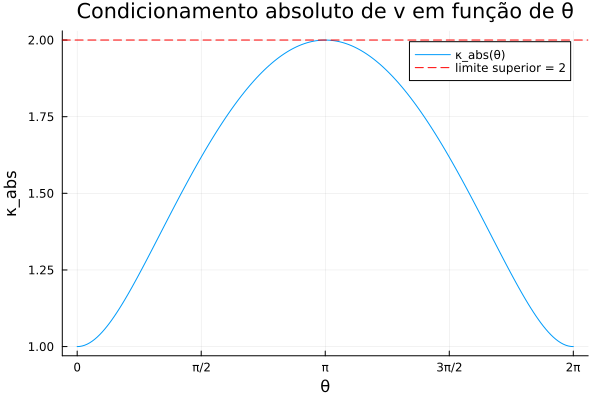

In [6]:
function jacobiano(x)
    n = length(x)
    norm_x = norm(x)
    # J = I - e1 * x' / ||x||
    J = Matrix{Float64}(I, n, n)
    J[1, :] -= x / norm_x # modifica somente a primeira linha
    return J
end

function x_cos_sin(θ, size, tipo) # parametro size para a proxima questão, não necessariamente usado aqui
    return tipo[cos(θ), sin(θ)]
end

thetas = range(0, 2π, length = 200)
cond = []
for θ in thetas
    x = x_cos_sin(θ, 2, Float64)
    push!(cond, maximum(svdvals(jacobiano(x)))
)
end
println("valor maximo: ", maximum(cond))

plot(thetas, cond,
    xlabel = "θ",
    ylabel = "κ_abs",
    title  = "Condicionamento absoluto de v em função de θ",
    label  = "κ_abs(θ)",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    hline! = [2.0],  # linha de referência no limite superior
)
hline!([2.0], label="limite superior = 2", linestyle=:dash, color=:red)

Nesse caso, quanto mais longe $x$ está de $e_1$ mais $v$ "estica" as perturbações e $\theta = \pi$ é o ponto mais distante de $e_1$ no círculo.

---

$(e)$ Uma ideia seria testar com vetores rodando o $\mathbb{R}^2$

In [ ]:
function x_randn(parameter, size, tipo)
    return randn(tipo, Int(size))
end

function testar_reflector(parameter, size, tipo, func)
    x = func(parameter, size, tipo)
    v, β = reflector(x)
    
    # verifica tipos
    if (eltype(x) != eltype(v)) || (eltype(x) != typeof(β)) 
        error("tipos diferentes")
    end

    # verifica que Qx ≈ ||x||e1
    Qx = x - β * (v' * x) * v   # aplica o refletor sem montar a matriz
    e1 = zeros(tipo, size)
    e1[1] = one(tipo)
    return norm(Qx - norm(x) * e1)

end

# teste com x_cos_sin
err_cos_sin_f32 = []
err_cos_sin_f64 = []

for θ in thetas
    push!(err_cos_sin_f32, testar_reflector(θ, 2, Float32, x_cos_sin))
    push!(err_cos_sin_f64, testar_reflector(θ, 2, Float64, x_cos_sin))
end

# teste com randn
err_randn_f32 = []
err_randn_f64 = []
sizes = 50:50:5000
for s in sizes
    push!(err_randn_f32, testar_reflector(0, s, Float32, x_randn))
    push!(err_randn_f64, testar_reflector(0, s, Float64, x_randn))
end

println("Float32")
println("eps da máquina: ", eps(Float32))
println("erro máximo com x = (cos(θ), sin(θ)) - Float32: ", maximum(err_cos_sin_f32))
println("erro médio com x = (cos(θ), sin(θ)) - Float32: ", mean(err_cos_sin_f32))
println()
println("erro máximo com x = randn(n) - Float32: ", maximum(err_randn_f32))
println("erro médio com x = randn(n) - Float32: ", mean(err_randn_f32))

println("\n")

println("Float64")
println("eps da máquina: ", eps(Float64))
println("erro máximo com x = (cos(θ), sin(θ)) - Float64: ", maximum(err_cos_sin_f64))
println("erro médio com x = (cos(θ), sin(θ)) - Float64: ", mean(err_cos_sin_f64))
println()
println("erro máximo com x = randn(n) - Float64: ", maximum(err_randn_f64))
println("erro médio com x = randn(n) - Float64: ", mean(err_randn_f64))

Float32
eps da máquina: 1.1920929e-7
erro máximo com x = (cos(θ), sin(θ)) - Float32: 8.419156e-7
erro médio com x = (cos(θ), sin(θ)) - Float32: 9.211051e-8

erro máximo com x = randn(n) - Float32: 0.0001953626
erro médio com x = randn(n) - Float32: 2.9936224e-5


Float64
eps da máquina: 2.220446049250313e-16
erro máximo com x = (cos(θ), sin(θ)) - Float64: 3.219646771412954e-15
erro médio com x = (cos(θ), sin(θ)) - Float64: 1.8103080084179437e-16

erro máximo com x = randn(n) - Float64: 3.191613762304833e-13
erro médio com x = randn(n) - Float64: 4.178970881785925e-14


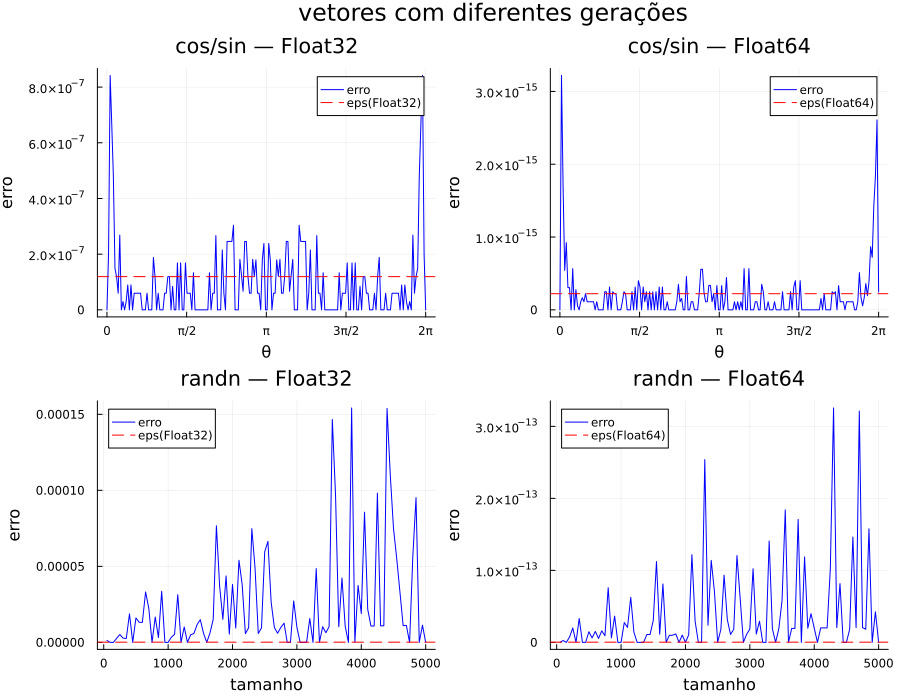

In [8]:
p1 = plot(thetas, err_cos_sin_f32,
    title  = "cos/sin — Float32",
    xlabel = "θ",
    ylabel = "erro",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    hline! = [eps(Float32)],
    label  = "erro",
    color  = :blue)
hline!(p1, [eps(Float32)], label="eps(Float32)", linestyle=:dash, color=:red)

p2 = plot(thetas, err_cos_sin_f64,
    title  = "cos/sin — Float64",
    xlabel = "θ",
    ylabel = "erro",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    label  = "erro",
    color  = :blue)
hline!(p2, [eps(Float64)], label="eps(Float64)", linestyle=:dash, color=:red)

p3 = plot(sizes, err_randn_f32,
    title  = "randn — Float32",
    xlabel = "tamanho",
    ylabel = "erro",
    label  = "erro",
    color  = :blue)
hline!(p3, [eps(Float32)], label="eps(Float32)", linestyle=:dash, color=:red)

p4 = plot(sizes, err_randn_f64,
    title  = "randn — Float64",
    xlabel = "tamanho",
    ylabel = "erro",
    label  = "erro",
    color  = :blue)
hline!(p4, [eps(Float64)], label="eps(Float64)", linestyle=:dash, color=:red)

plot(p1, p2, p3, p4, layout=(2,2), size=(900,700), suptitle = "vetores com diferentes gerações")

Nos dois subsplots de cima, os erros ficam na ordem de $\epsilon$, com picos perto de $0$ e $2\pi$. Nesses valores $x \to e_1$, então $||y||_2 \to 0$. O denominador na fórmula de $\beta$ fica muito pequeno, amplificando o erro de arredondamento. Mas ainda assim com erros relativamente pequenos.

Nos dois prots de baixo vemos que o erro cresce com a dimensão, bem acima de $\epsilon$. Imagino que isso seja porque estamos somando $n$ termos com erros de arredondamento depois tirando a raiz quadrada, o que faria o erro crescer proporcional a $\sqrt{n}\epsilon$. Sendo assim, apenas um erro de ponto flutuante, não de instabilidade da função.

Nota-se também como a escolha de tipos influencia na precisão dos cálculos dessas funções.

---

$(f)$ Sabemos que para fazer a reflexão de $x$ em relação ao espaço no qual $v$ é ortgonal temos que subtrair de $x$ duas vezes a projeção de $x$ em $v$. Ou seja, $H = I - 2\frac{vv^*}{v^*v}$. Assim:
$$\beta = \frac{2}{v^*v}$$

In [ ]:
function calc_beta(v)
    vv = v' * v

    # caso em que x está exatamente alinhado com e1: v = x - ||x||e1 = 0
    if iszero(vv)
        return zero(eltype(v))
    end
    
    return 2 / (vv)
end

calc_beta (generic function with 1 method)

In [24]:
function testar_calc_beta(parameter, size, tipo, func)
    x = func(parameter, size, tipo)
    v, β_reflector = reflector(x)
    β_calc = calc_beta(v)

    # verifica tipos
    if typeof(β_calc) != tipo
        error("tipo errado: $(typeof(β_calc)) != $tipo")
    end

    # erro usando β de calc_beta
    Qx = x - β_calc * (v' * x) * v
    e1 = zeros(tipo, Int(size))
    e1[1] = one(tipo)

    return norm(Qx - norm(x) * e1), abs(β_reflector - β_calc)
end

err_calc_f32 = []
err_calc_f64 = []
diff_β_f32 = []
diff_β_f64 = []

for θ in thetas
    err_32, diff_32 = testar_calc_beta(θ, 2, Float32, x_cos_sin)    
    err_64, diff_64 = testar_calc_beta(θ, 2, Float64, x_cos_sin)

    push!(err_calc_f32, err_32)
    push!(err_calc_f64, err_64)
    push!(diff_β_f32, diff_32)
    push!(diff_β_f64, diff_64)
end

println("Float32")
println("eps da máquina: ", eps(Float32))
println("erro máximo com x = (cos(θ), sin(θ)) - Float32: ", maximum(err_calc_f32))
println("erro médio com x = (cos(θ), sin(θ)) - Float32: ", mean(err_calc_f32))
println()
println("max| β_calc - β_reflector | - Float32: ", maximum(err_randn_f32))
println("mean| β_calc - β_reflector | - Float32: ", mean(err_randn_f32))

println("\n")

println("Float64")
println("eps da máquina: ", eps(Float64))
println("erro máximo com x = (cos(θ), sin(θ)) - Float64: ", maximum(err_calc_f64))
println("erro médio com x = (cos(θ), sin(θ)) - Float64: ", mean(err_calc_f64))
println()
println("max| β_calc - β_reflector | - Float64: ", maximum(err_randn_f64))
println("mean| β_calc - β_reflector | - Float64: ", mean(err_randn_f64))

Float32
eps da máquina: 1.1920929e-7
erro máximo com x = (cos(θ), sin(θ)) - Float32: 8.493662e-7
erro médio com x = (cos(θ), sin(θ)) - Float32: 9.825152e-8

max| β_calc - β_reflector | - Float32: 0.0001953626
mean| β_calc - β_reflector | - Float32: 2.9936224e-5


Float64
eps da máquina: 2.220446049250313e-16
erro máximo com x = (cos(θ), sin(θ)) - Float64: 3.2127078775090467e-15
erro médio com x = (cos(θ), sin(θ)) - Float64: 1.8915648107618694e-16

max| β_calc - β_reflector | - Float64: 3.191613762304833e-13
mean| β_calc - β_reflector | - Float64: 4.178970881785925e-14


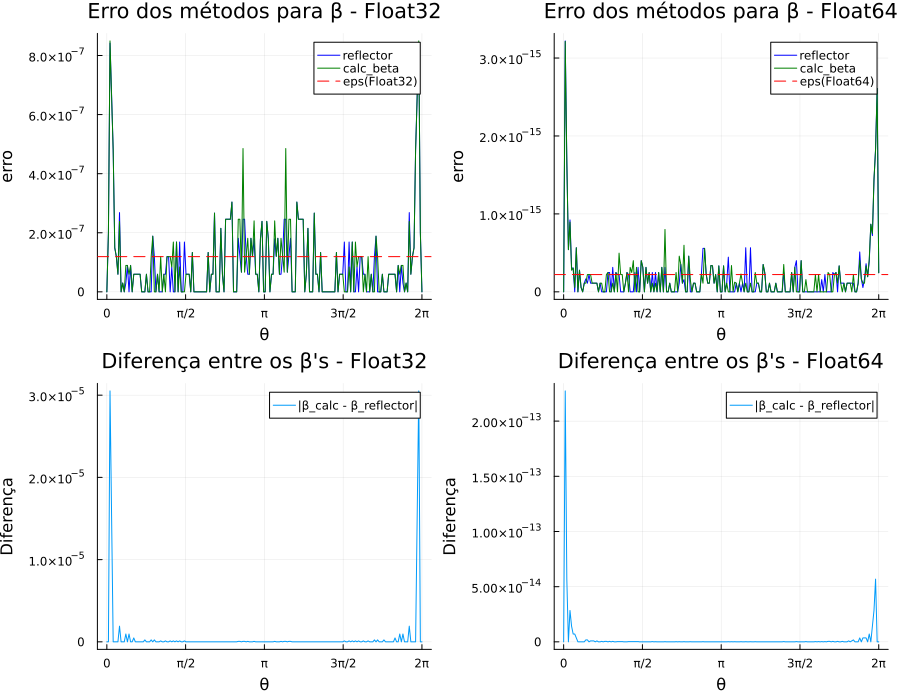

In [33]:
p1 = plot(thetas, err_cos_sin_f32, 
    label= "reflector", 
    title = "Erro dos métodos para β - Float32",
    xlabel = "θ",
    ylabel = "erro",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    color=:blue)
plot!(p1, thetas, err_calc_f32, 
    label="calc_beta", color=:green)
hline!(p1, [eps(Float32)], label="eps(Float32)", linestyle=:dash, color=:red)

p2 = plot(thetas, err_cos_sin_f64, 
    label="reflector",
    title = "Erro dos métodos para β - Float64",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    xlabel = "θ",
    ylabel = "erro",
    color=:blue)
plot!(p2, thetas, err_calc_f64, label="calc_beta", color=:green)
hline!(p2, [eps(Float64)], label="eps(Float64)", linestyle=:dash, color=:red)

p3 = plot(thetas, diff_β_f32,
    label = "|β_calc - β_reflector|",
    title = "Diferença entre os β's - Float32",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    xlabel = "θ",
    ylabel = "Diferença")

p4 = plot(thetas, diff_β_f64,
    label = "|β_calc - β_reflector|",
    title = "Diferença entre os β's - Float64",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    xlabel = "θ",
    ylabel = "Diferença",)
    

plot(p1,p2,p3,p4, layout = (2,2), size=(900,700))

Nos dois subplots de cima as curvas azul (reflector) e verde (calc_beta) estão praticamente sobrepostas nos dois tipos. Isso confirma o que o enunciado afirma: "Não há muita diferença ao calcular $\beta$ a partir de $x$ ou apenas de $v$".

Quanto a análise dos dois subplots de baixo, os $\beta 's$ calculados são identicos na maior parte do domínio. divergem ligeiramente quando temos $x \approx e_1$

---

$(g)$ (Bônus)

# Questão 2. Forma de Hessemberg

$(a)$

$(b)$

$(c)$

$(d)$

$(e)$

$(f)$

# Questão 3. Exponenciais de matrizes

$(a)$

$(b)$

$(c)$ (Bônus)